# Formula 1 Tire Degradation Analysis

By Sami Krothapalli

- This project studies whether Formula 1 tires lose performance gradually or whether there is a tire age where lap times begin to get much worse. 

- The main response variable is `PaceDelta_Adjusted`, which measures how much faster or slower a lap was after accounting for race progress like fuel loss, driver, Grand Prix, and year.


## Step 1: Import Data

The dataset comes from the AeroSpeed Analytics Kaggle dataset. 
- Dataset: https://www.kaggle.com/datasets/shivmahlan/aerospeed-analytics?resource=download


For this project, the main file is `f1_race_laps.csv`
-  Columns:
    - lap time
    - tire life 
    - compound 
    - pit-stop information, 
    - track status
    - driver 
    - race
    - year.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from patsy import bs

sns.set_theme(style="whitegrid")

data_folder = "data/F1 Dataset"
laps = pd.read_csv(f"{data_folder}/f1_race_laps.csv")

print(laps.shape)
laps.head()


(73398, 24)


,Driver,DriverNumber,Team,LapTime,LapNumber,Compound,TyreLife,FreshTyre,SpeedI1,SpeedI2,...,Sector3Time,PitInTime,PitOutTime,TrackStatus,IsAccurate,GP,Location,Year,Round,HasPitStop
0,VER,1,Red Bull Racing,100.236,1.0,SOFT,4.0,False,230.0,254.0,...,24.389,NaN,NaN,1,False,Bahrain Grand Prix,Sakhir,2022,1,False
1,VER,1,Red Bull Racing,97.880,2.0,SOFT,5.0,False,230.0,252.0,...,24.326,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
2,VER,1,Red Bull Racing,98.357,3.0,SOFT,6.0,False,229.0,254.0,...,24.384,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
3,VER,1,Red Bull Racing,98.566,4.0,SOFT,7.0,False,231.0,250.0,...,24.550,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
4,VER,1,Red Bull Racing,98.877,5.0,SOFT,8.0,False,229.0,256.0,...,24.525,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False


## Step 2: Clean & Validation

### 2a: Race Laps

We only want laps that represent normal dry racing pace and removing everything else


In [67]:
clean_laps = laps.copy()

clean_laps = clean_laps[
    (clean_laps["IsAccurate"] == True) &
    (clean_laps["HasPitStop"] == False) &
    (clean_laps["PitInTime"].isna()) &
    (clean_laps["PitOutTime"].isna()) &
    (clean_laps["TrackStatus"] == 1) &
    (clean_laps["Compound"].isin(["SOFT", "MEDIUM", "HARD"])) &
    (clean_laps["LapTime"].notna()) &
    (clean_laps["TyreLife"].notna())
].copy()

print("Original rows:", laps.shape[0])
print("Rows after cleaning:", clean_laps.shape[0])
clean_laps[["Driver", "GP", "Year", "LapNumber", "LapTime", "Compound", "TyreLife"]].head()


Original rows: 73398
Rows after cleaning: 58521


,Driver,GP,Year,LapNumber,LapTime,Compound,TyreLife
1,VER,Bahrain Grand Prix,2022,2.0,97.880,SOFT,5.0
2,VER,Bahrain Grand Prix,2022,3.0,98.357,SOFT,6.0
3,VER,Bahrain Grand Prix,2022,4.0,98.566,SOFT,7.0
4,VER,Bahrain Grand Prix,2022,5.0,98.877,SOFT,8.0
5,VER,Bahrain Grand Prix,2022,6.0,98.940,SOFT,9.0


### 2b: Validate Data Support by Tire Age

Before interpreting tire degradation, we need to know how many laps exist at each tire age

- If a tire age has very few laps the average pace at that point may be unstable


In [68]:
tire_life_counts = (
    clean_laps
    .groupby(["Compound", "TyreLife"])
    .size()
    .reset_index(name="LapCount")
)

tire_life_counts.head()


,Compound,TyreLife,LapCount
0,HARD,2.0,852
1,HARD,3.0,1020
2,HARD,4.0,1011
3,HARD,5.0,1061
4,HARD,6.0,1082


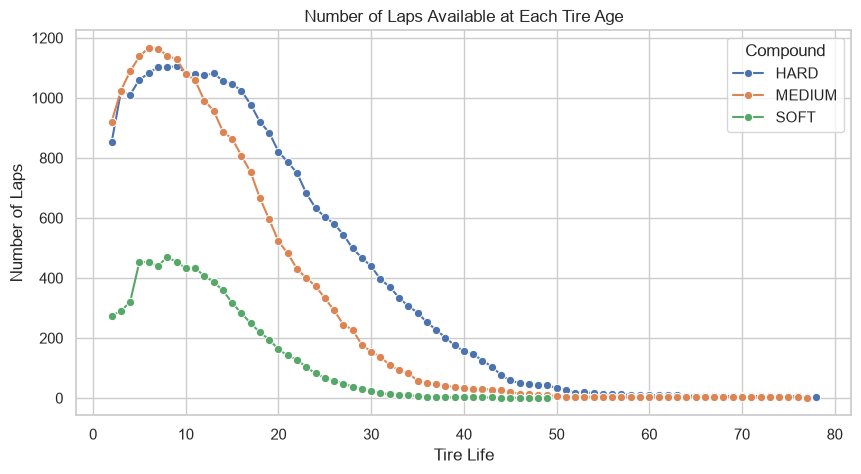

In [69]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tire_life_counts,
    x="TyreLife",
    y="LapCount",
    hue="Compound",
    marker="o"
)

plt.title("Number of Laps Available at Each Tire Age")
plt.xlabel("Tire Life")
plt.ylabel("Number of Laps")
plt.grid(True)
plt.show()


 From the graph we can see that soft tires have fewer long-stint observations while hard tires are observed over longer tire ages 
 
 - Conclusion: Since observations are very sparse at high tire ages we will only analysis compound/tire-age combinations with at least 30 laps


In [73]:
reliable_points = tire_life_counts[tire_life_counts["LapCount"] >= 30]

clean_laps_reliable = clean_laps.merge(
    reliable_points[["Compound", "TyreLife"]],
    on=["Compound", "TyreLife"],
    how="inner"
).copy()

print("Rows after cleaning:", clean_laps.shape[0])
print("Rows after reliability filter:", clean_laps_reliable.shape[0])


Rows after cleaning: 58521
Rows after reliability filter: 57891


## Step 4: Create Response Variable + Degradation Plot


Since raw lap time is not a fair response variable because different races have different lap lengths and later race laps are affected by fuel burn

- As car burns fuel -> it becomes lighter -> faster lap time -> older tires look faster simply because they occur later in the race

So we model lap time using race lap number, driver, Grand Prix, and year. The residual from this model becomes 

`PaceDelta_Adjusted = actual lap time - E(lap time w/ race context)`

- Negative values =  lap was faster than expected 
- Positive values =  lap was slower than expected


In [78]:
clean_laps_reliable = clean_laps_reliable.sort_values(
    ["Year", "Round", "Driver", "LapNumber"]
).copy()

fuel_adjustment_model = smf.ols(
    "LapTime ~ LapNumber + C(Driver) + C(GP) + C(Year)",
    data=clean_laps_reliable
).fit()

clean_laps_reliable["PaceDelta_Adjusted"] = fuel_adjustment_model.resid

clean_laps_reliable[["LapTime", "LapNumber", "TyreLife", "Compound", "PaceDelta_Adjusted"]].head()


,LapTime,LapNumber,TyreLife,Compound,PaceDelta_Adjusted
340,100.548,2.0,2.0,SOFT,-0.478788
341,100.664,3.0,3.0,SOFT,-0.321255
342,101.126,4.0,4.0,SOFT,0.182277
343,102.303,5.0,5.0,SOFT,1.400809
344,101.708,6.0,6.0,SOFT,0.847342


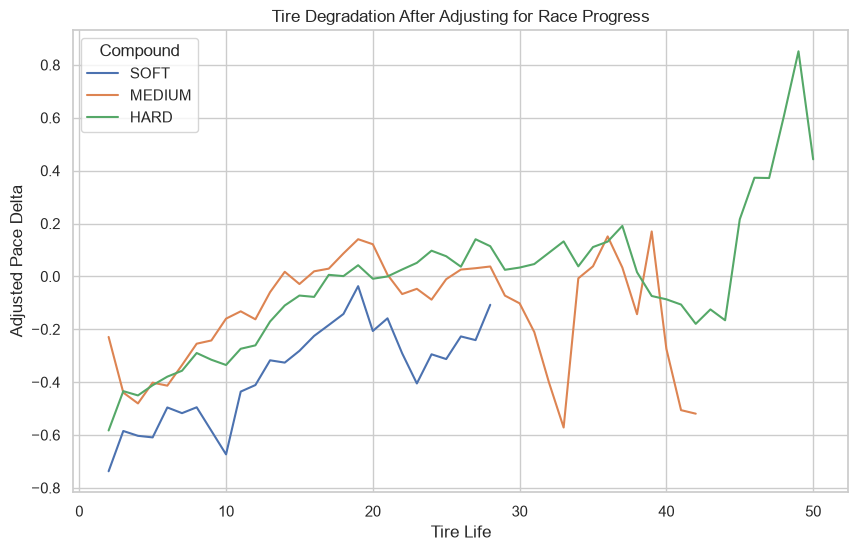

In [79]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=clean_laps_reliable,
    x="TyreLife",
    y="PaceDelta_Adjusted",
    hue="Compound",
    estimator="median",
    errorbar=None
)

plt.title("Tire Degradation After Adjusting for Race Progress")
plt.xlabel("Tire Life")
plt.ylabel("Adjusted Pace Delta")
plt.grid(True)
plt.show()


Median adjusted pace delta at each tire age for soft, medium, and hard compounds. An upward trend means tires are becoming slower after accounting for race progress and driver/race differences.


# Spline

## Fit Spline Model

In [93]:
spline_model = smf.ols(
    "PaceDelta_Adjusted ~ bs(TyreLife, df=6) + C(Compound)",
    data=clean_laps_reliable
).fit()

print(spline_model.summary())


                            OLS Regression Results                            
Dep. Variable:     PaceDelta_Adjusted   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     62.63
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          1.23e-102
Time:                        02:32:28   Log-Likelihood:            -1.2807e+05
No. Observations:               57891   AIC:                         2.562e+05
Df Residuals:                   57882   BIC:                         2.562e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.25

In [94]:
prediction_data = pd.DataFrame({
    "TyreLife": list(range(2, 51)) * 3,
    "Compound": ["SOFT"] * 49 + ["MEDIUM"] * 49 + ["HARD"] * 49
})

prediction_data["SplinePrediction"] = spline_model.predict(prediction_data)
prediction_data.head()


,TyreLife,Compound,SplinePrediction
0,2,SOFT,0.640473
1,3,SOFT,0.259211
2,4,SOFT,0.052788
3,5,SOFT,-0.024702
4,6,SOFT,-0.019160


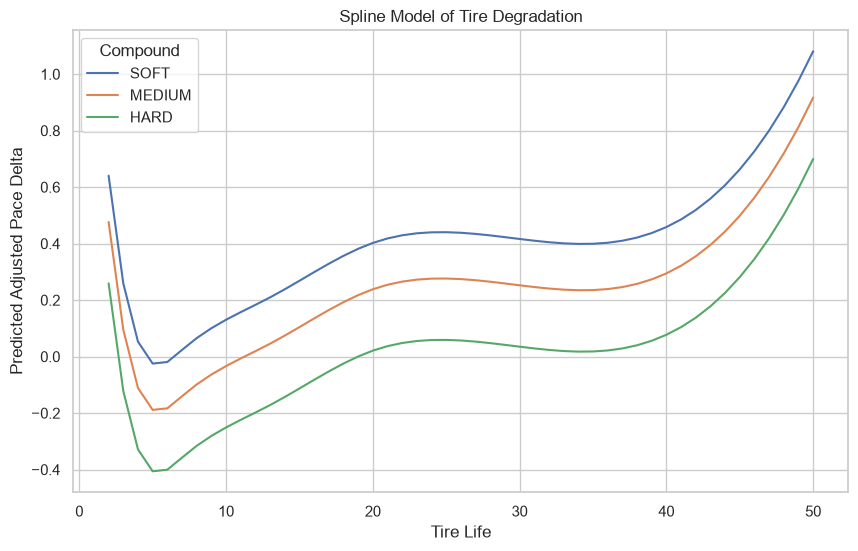

In [95]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=prediction_data,
    x="TyreLife",
    y="SplinePrediction",
    hue="Compound"
)

plt.title("Spline Model of Tire Degradation")
plt.xlabel("Tire Life")
plt.ylabel("Predicted Adjusted Pace Delta")
plt.grid(True)
plt.show()


### Interpretation of Spline Model

The model suggest that tire performance changes nonlinearly over a stint. The curves improve briefly early in the stint, which may reflect tire warm-up, and then generally rise as tire life increases. A rising curve means the lap is becoming slower than expected after accounting for race progress, driver, Grand Prix, and year.

Soft tires show the highest predicted pace loss, medium tires are in the middle, and hard tires show the lowest predicted pace loss for much of the stint. The sharp rise at high tire ages should be interpreted cautiously because the count plot showed fewer observations at those ages.

# Segemented Regression

At what tire age does the degradation rate change?

In [90]:
# Func for Segmented Regression
def fit_segmented_model(data , breakpoint):
    data["AfterBreakpoint"] = np.maximum(0, data["TyreLife"] - breakpoint)
    
    model = smf.ols(
        "PaceDelta_Adjusted ~ TyreLife + AfterBreakpoint",
        data=data
    ).fit()
    
    return model

Breakpoints from 5 to 40

In [91]:
breakpoint_results = []

for compound in ["SOFT", "MEDIUM", "HARD"]:
    compound_data = clean_laps_reliable[
        clean_laps_reliable["Compound"] == compound
    ].copy()
    
    for breakpoint in range(5, 41):
        model = fit_segmented_model(compound_data, breakpoint)
        
        breakpoint_results.append({
            "Compound": compound,
            "Breakpoint": breakpoint,
            "AIC": model.aic,
            "BeforeSlope": model.params["TyreLife"],
            "AfterSlopeChange": model.params["AfterBreakpoint"],
            "AfterSlope": model.params["TyreLife"] + model.params["AfterBreakpoint"]
        })

breakpoint_results = pd.DataFrame(breakpoint_results)

breakpoint_results.head()

,Compound,Breakpoint,AIC,BeforeSlope,AfterSlopeChange,AfterSlope
0,SOFT,5,38562.598859,-0.438014,0.451714,0.013699
1,SOFT,6,38554.465006,-0.335526,0.357729,0.022203
2,SOFT,7,38552.069118,-0.260671,0.290325,0.029655
3,SOFT,8,38555.276501,-0.202182,0.237317,0.035136
4,SOFT,9,38560.550642,-0.159258,0.198928,0.039670


In [92]:
best_breakpoints = (
    breakpoint_results
    .sort_values("AIC")
    .groupby("Compound")
    .head(1)
    .sort_values("Compound")
)

best_breakpoints

,Compound,Breakpoint,AIC,BeforeSlope,AfterSlopeChange,AfterSlope
92,HARD,25,108989.131377,0.021734,-0.015187,0.006547
36,MEDIUM,5,99625.536217,-0.170647,0.184667,0.014019
2,SOFT,7,38552.069118,-0.260671,0.290325,0.029655


- Hard Tires:
    - Hard Tires get slightly slower before titre age 25 but the slope becomes smaller after 25 -> Doesn't look like gradual degradation
- Soft Tires
    -  Before age 7 soft tires improve quickly after 7 they start getting slower -> Breakpoint is the start of degradation
- Meduim Tires
    - Before Age5 tires get faster after tire age 5 they start getting slower gradually -> Breakpoint is probaly from warming up the tires not reall a cliff for tire degradation

In [96]:
segmented_prediction_data = []

for _, row in best_breakpoints.iterrows():
    compound = row["Compound"]
    breakpoint = row["Breakpoint"]

    compound_data = clean_laps_reliable[
        clean_laps_reliable["Compound"] == compound
    ].copy()

    model = fit_segmented_model(compound_data, breakpoint)

    tyre_life_range = range(
        int(compound_data["TyreLife"].min()),
        int(compound_data["TyreLife"].max()) + 1
    )

    for tyre_life in tyre_life_range:
        after_breakpoint = max(0, tyre_life - breakpoint)

        prediction = model.predict(pd.DataFrame({
            "TyreLife": [tyre_life],
            "AfterBreakpoint": [after_breakpoint]
        }))[0]

        segmented_prediction_data.append({
            "Compound": compound,
            "TyreLife": tyre_life,
            "PredictedPaceDelta": prediction,
            "Breakpoint": breakpoint
        })

segmented_predictions = pd.DataFrame(segmented_prediction_data)

segmented_predictions.head()

,Compound,TyreLife,PredictedPaceDelta,Breakpoint
0,HARD,2,-0.398812,25
1,HARD,3,-0.377078,25
2,HARD,4,-0.355344,25
3,HARD,5,-0.333610,25
4,HARD,6,-0.311876,25


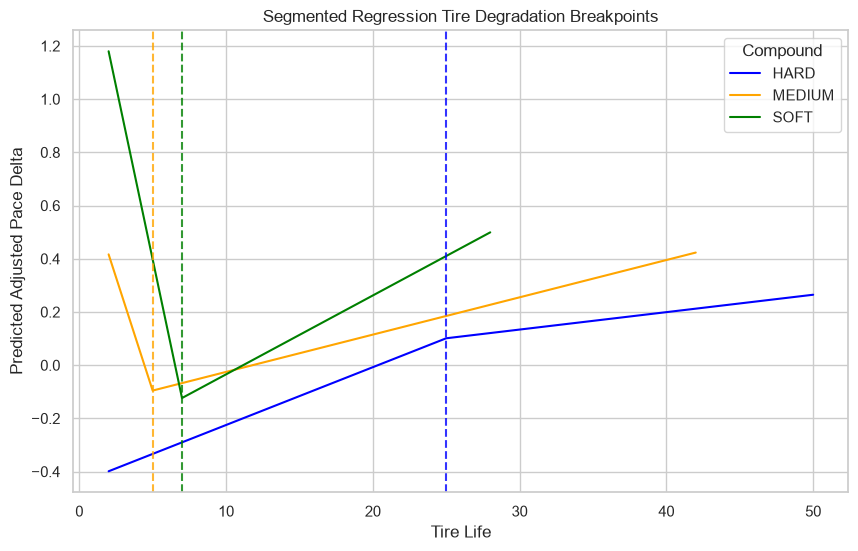

In [98]:
plt.figure(figsize=(10, 6))

compound_colors = {
    "SOFT": "green",
    "MEDIUM": "orange",
    "HARD": "blue"
}

sns.lineplot(
    data=segmented_predictions,
    x="TyreLife",
    y="PredictedPaceDelta",
    hue="Compound",
    palette=compound_colors
)

for _, row in best_breakpoints.iterrows():
    plt.axvline(
        x=row["Breakpoint"],
        color=compound_colors[row["Compound"]],
        linestyle="--",
        alpha=0.8
    )

plt.title("Segmented Regression Tire Degradation Breakpoints")
plt.xlabel("Tire Life")
plt.ylabel("Predicted Adjusted Pace Delta")
plt.grid(True)
plt.show()

Conclusion: Semented Regression estimated early breakpoints for soft and meduim tires but these appear to represent the transition from warm up to degradation rather than a sudden late tire cliff

# Regression Trees

Want to be able to determine which variables help redict wheter a lap is slower than expected

## Create Tree Dataset

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

Variables like Sector 2Time and Sector 3Time are a part of LapTime which makes it closly related to response varibale so we need to remove that and incoerparate predictorrs that we would know before or duirng a lap

In [114]:
tree_data = clean_laps_reliable[
    [
        "PaceDelta_Adjusted",
        "TyreLife",
        "LapNumber",
        "Compound",
        "FreshTyre",
        "SpeedI1",
        "SpeedI2",
        "SpeedFL",
        "SpeedST",
        "Team",
        "GP",
        "Year"
    ]
].dropna().copy()

tree_data = pd.get_dummies(
    tree_data,
    columns=["Compound", "FreshTyre", "Team", "GP", "Year"],
    drop_first=True
)

X = tree_data.drop(columns=["PaceDelta_Adjusted"])
y = tree_data["PaceDelta_Adjusted"]

print(X.shape)

(57891, 46)


In [115]:
## Split into Traning and Test Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=444
)

## Fit Regression Tree
tree_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    random_state=444
)

tree_model.fit(X_train, y_train)

## Evaluate
tree_predictions = tree_model.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))

print("Regression Tree RMSE:", tree_rmse)

Regression Tree RMSE: 1.9934819912049409


## Plotted Regreession Tree

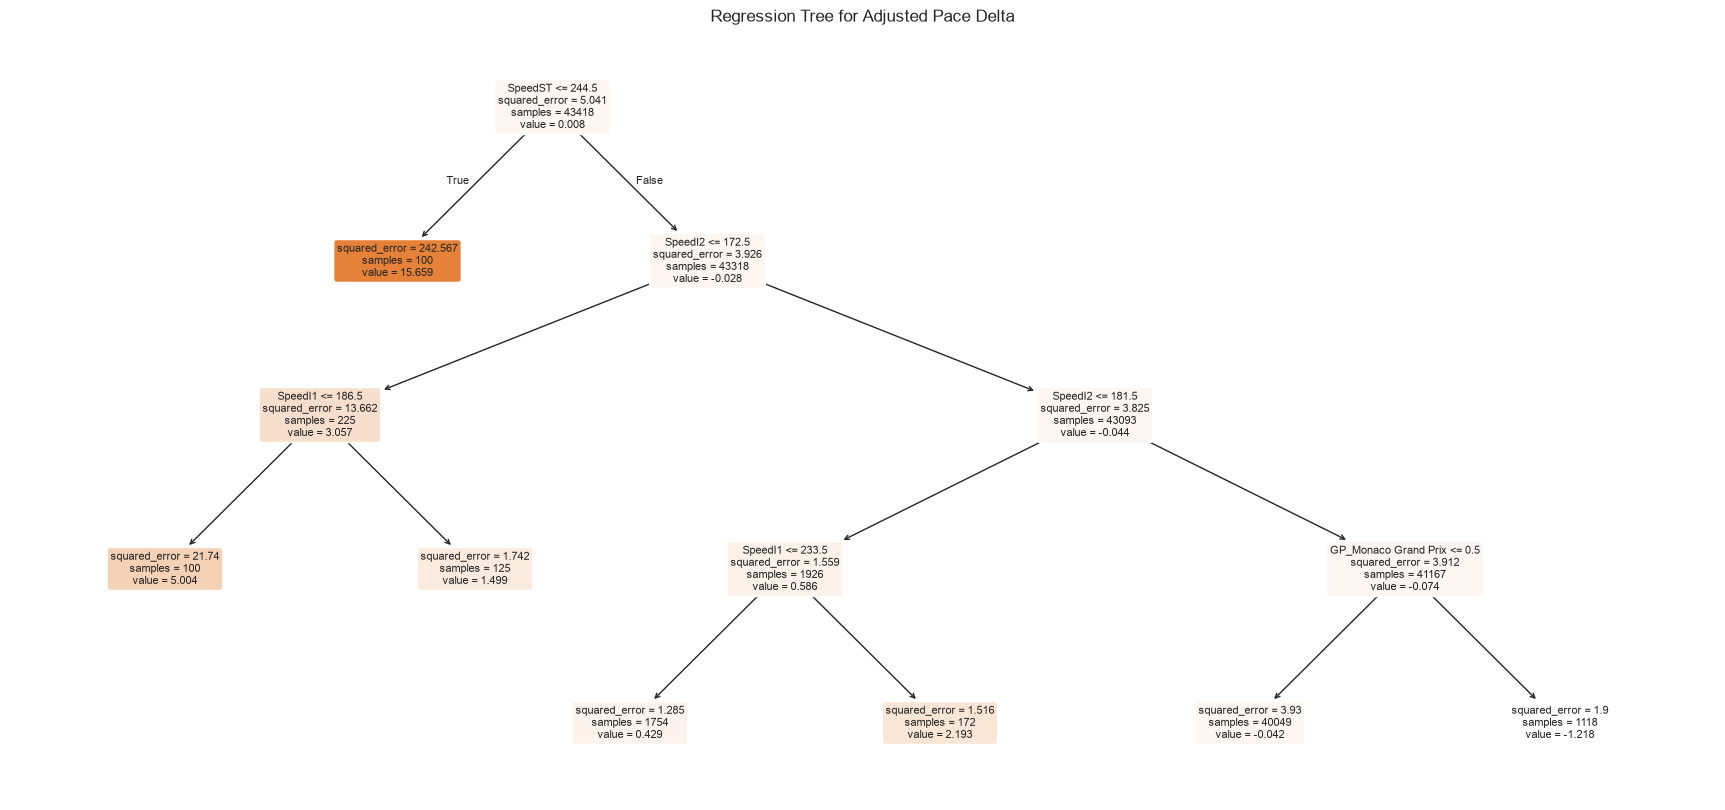

In [116]:
plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Regression Tree for Adjusted Pace Delta")
plt.show()

Regression tree foudn that speed and race context were stronger predictors of Pace Delta than tire age alone


- it found that pace loss is dependent more on speed measures and race context but there is some evidnce that pace depends on tire performance as well


# Model Comparison

We compare the RMSE on a test set with each of the 3 methods

In [117]:
# Use  same rows and split for spline and segmented regression comparison
model_data = clean_laps_reliable[
    ["PaceDelta_Adjusted", "TyreLife", "Compound"]
].dropna().copy()

train_data, test_data = train_test_split(
    model_data,
    test_size=0.25,
    random_state=444,
    stratify=model_data["Compound"]
)

print(train_data.shape)
print(test_data.shape)

(43418, 3)
(14473, 3)


In [118]:
# Spline test RMSE
spline_compare_model = smf.ols(
    "PaceDelta_Adjusted ~ bs(TyreLife, df=6) + C(Compound)",
    data=train_data
).fit()

spline_test_predictions = spline_compare_model.predict(test_data)

spline_rmse = np.sqrt(
    mean_squared_error(test_data["PaceDelta_Adjusted"], spline_test_predictions)
)

print("Spline RMSE:", spline_rmse)

Spline RMSE: 2.2585875007090963


In [119]:
# Segmented regression test RMSE
segmented_test_predictions = []
segmented_test_actuals = []
segmented_compare_results = []

for compound in ["SOFT", "MEDIUM", "HARD"]:
    compound_train = train_data[train_data["Compound"] == compound].copy()
    compound_test = test_data[test_data["Compound"] == compound].copy()

    compound_breakpoint_results = []

    for breakpoint in range(5, 41):
        model = fit_segmented_model(compound_train.copy(), breakpoint)

        compound_breakpoint_results.append({
            "Breakpoint": breakpoint,
            "AIC": model.aic
        })

    best_breakpoint = (
        pd.DataFrame(compound_breakpoint_results)
        .sort_values("AIC")
        .iloc[0]["Breakpoint"]
    )

    final_segmented_model = fit_segmented_model(
        compound_train.copy(),
        best_breakpoint
    )

    compound_test["AfterBreakpoint"] = np.maximum(
        0,
        compound_test["TyreLife"] - best_breakpoint
    )

    predictions = final_segmented_model.predict(compound_test)

    segmented_test_predictions.extend(predictions)
    segmented_test_actuals.extend(compound_test["PaceDelta_Adjusted"])

    segmented_compare_results.append({
        "Compound": compound,
        "SelectedBreakpoint": best_breakpoint
    })

segmented_rmse = np.sqrt(
    mean_squared_error(segmented_test_actuals, segmented_test_predictions)
)

print("Segmented Regression RMSE:", segmented_rmse)

pd.DataFrame(segmented_compare_results)

Segmented Regression RMSE: 2.2566558209201535


,Compound,SelectedBreakpoint
0,SOFT,7.0
1,MEDIUM,5.0
2,HARD,24.0


In [120]:
# Regression tree RMSE was already calculated in the tree section as tree_rmse
comparison_table = pd.DataFrame({
    "Model": ["Spline", "Segmented Regression", "Regression Tree"],
    "RMSE": [spline_rmse, segmented_rmse, tree_rmse]
}).sort_values("RMSE")

comparison_table

,Model,RMSE
2,Regression Tree,1.993482
1,Segmented Regression,2.256656
0,Spline,2.258588


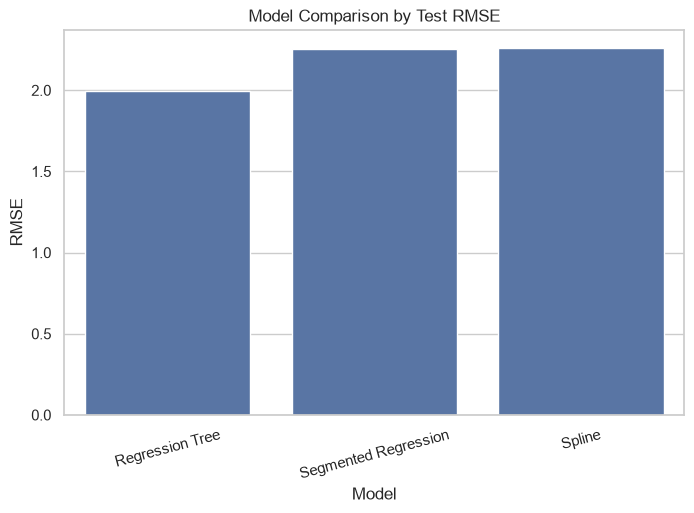

In [121]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison by Test RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(True, axis="y")
plt.show()